In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

base    = r'C:\Users\chant\ecommerce-analytics\data\raw'
out     = r'C:\Users\chant\ecommerce-analytics\data\processed'
models  = r'C:\Users\chant\ecommerce-analytics\models'
os.makedirs(models, exist_ok=True)

products  = pd.read_csv(os.path.join(base, 'products.csv'))
inventory = pd.read_csv(os.path.join(base, 'inventory.csv'), parse_dates=['snapshot_date'])
print("Data loaded:", inventory.shape)

Data loaded: (3650, 4)


In [2]:
# merge inventory with product metadata
df = inventory.merge(products[['product_id','category','reorder_point',
                                'is_perishable','price']], on='product_id', how='left')

# time-based features
df['month']      = df['snapshot_date'].dt.month
df['day_of_week']= df['snapshot_date'].dt.dayofweek
df['quarter']    = df['snapshot_date'].dt.quarter

# stock health ratio
df['stock_ratio'] = df['stock_level'] / (df['reorder_point'] + 1)

# rolling 7-day avg stock per product
df = df.sort_values(['product_id','snapshot_date'])
df['rolling_avg_stock'] = (df.groupby('product_id')['stock_level']
                             .transform(lambda x: x.rolling(7, min_periods=1).mean()))

# encode category
le = LabelEncoder()
df['category_enc'] = le.fit_transform(df['category'].fillna('Unknown'))
df['is_perishable'] = df['is_perishable'].astype(int)

# target & features
features = ['stock_level','reorder_point','stock_ratio','rolling_avg_stock',
            'month','day_of_week','quarter','category_enc','is_perishable','price']
target   = 'stockout_event'

df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target].astype(int)

print(f"Dataset shape  : {X.shape}")
print(f"Stockout rate  : {y.mean()*100:.1f}%")
print(f"Class balance  : {y.value_counts().to_dict()}")

Dataset shape  : (3650, 10)
Stockout rate  : 8.2%
Class balance  : {0: 3352, 1: 298}


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("Model trained successfully")
print(f"\nROC-AUC Score : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Stockout','Stockout']))

Model trained successfully

ROC-AUC Score : 0.4523

Classification Report:

              precision    recall  f1-score   support

 No Stockout       0.92      0.89      0.90       670
    Stockout       0.07      0.10      0.08        60

    accuracy                           0.82       730
   macro avg       0.49      0.49      0.49       730
weighted avg       0.85      0.82      0.83       730



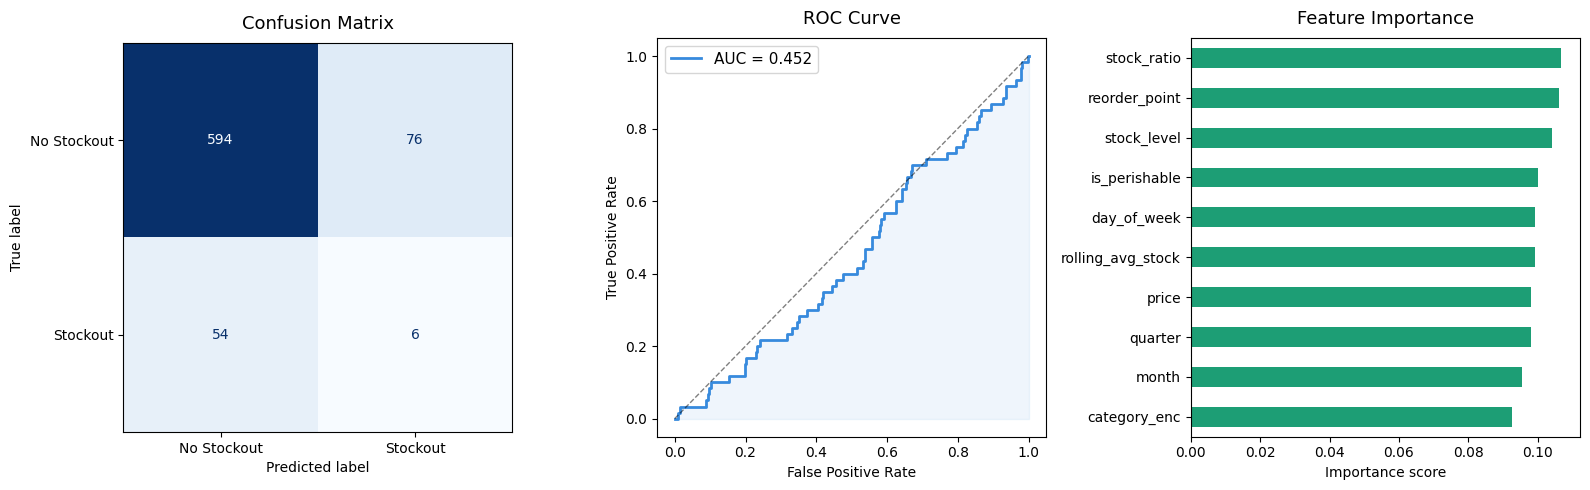

Model saved to models/stockout_model.pkl


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Stockout','Stockout'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, pad=10)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#378ADD', lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#378ADD')
axes[1].set_title('ROC Curve', fontsize=13, pad=10)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=11)

# feature importance
feat_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[2], color='#1D9E75', edgecolor='none')
axes[2].set_title('Feature Importance', fontsize=13, pad=10)
axes[2].set_xlabel('Importance score')

plt.tight_layout()
plt.savefig(os.path.join(out, 'model1_stockout_evaluation.png'), dpi=150)
plt.show()

# save model
joblib.dump(model, os.path.join(models, 'stockout_model.pkl'))
joblib.dump(le,    os.path.join(models, 'category_encoder.pkl'))
print(f"Model saved to models/stockout_model.pkl")

In [5]:
# score today's snapshot (latest date in inventory)
latest = df[df['snapshot_date'] == df['snapshot_date'].max()].copy()
latest_X = latest[features].fillna(0)
latest['stockout_risk_score'] = model.predict_proba(latest_X)[:, 1]
latest['risk_label'] = pd.cut(latest['stockout_risk_score'],
                               bins=[0, 0.3, 0.6, 1.0],
                               labels=['Low', 'Medium', 'High'])

risk_summary = latest.groupby(['category','risk_label']).size().unstack(fill_value=0)
print("\nStockout Risk Summary (latest snapshot):")
print(risk_summary)

top_risk = latest.nlargest(10, 'stockout_risk_score')[
    ['product_id','category','stock_level','stockout_risk_score','risk_label']]
print(f"\nTop 10 highest-risk products:")
print(top_risk.to_string(index=False))

latest[['product_id','category','stock_level','stockout_risk_score','risk_label']].to_csv(
    os.path.join(out, 'stockout_risk_scores.csv'), index=False)
print("\nRisk scores saved to data/processed/stockout_risk_scores.csv")


Stockout Risk Summary (latest snapshot):
risk_label   Low  Medium  High
category                      
Beauty         0       1     1
Electronics    1       1     1
Fashion        0       1     1
Grocery        2       0     1

Top 10 highest-risk products:
product_id    category  stock_level  stockout_risk_score risk_label
     P0387      Beauty           91             0.827080       High
     P0446     Fashion          562             0.741009       High
     P0042     Grocery          444             0.709717       High
     P0096 Electronics          338             0.685402       High
     P0143     Fashion          432             0.582777     Medium
     P0352      Beauty          219             0.437794     Medium
     P0134 Electronics          487             0.391756     Medium
     P0116 Electronics          457             0.125741        Low
     P0113     Grocery          310             0.110851        Low
     P0270     Grocery          260             0.067030     